<a href="https://colab.research.google.com/github/Madhuanabala/breast-cancer/blob/model-validations/pickel_for_extraclassifier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dask[dataframe]

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, mean_absolute_error, cohen_kappa_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pandas as pd

In [ ]:
np.random.seed(42)
random.seed(42)

In [ ]:
df = pd.read_csv('/content/combined_dataset_fs_2.csv')
df

,Unnamed: 0,KRFP17,KRFP1146,KRFP1157,KRFP2667,KRFP2986,KRFP3058,KRFP3180,KRFP3360,KRFP3395,...,BCUT2D_CHGHI_1.0,BCUT2D_CHGLO_1.0,BCUT2D_MRHI_2.0,Chi4n_0,PEOE_VSA6_0,SlogP_VSA11_0,RingCount_0,fr_NH0_0,fr_aniline_0,fr_aryl_methyl_0
0,0,1,0,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
1,1,1,1,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
2,2,1,0,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
3,3,0,0,0,0,1,0,0,0,0,...,1,1,0,1,1,1,1,1,1,1
4,4,0,0,0,0,1,0,0,0,0,...,1,1,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1812,1812,0,0,0,0,1,1,0,0,0,...,1,0,0,1,1,1,0,1,1,1
1813,1813,0,0,0,0,1,1,0,0,0,...,1,0,0,1,1,1,0,1,1,1
1814,1814,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,0,1,1
1815,1815,0,1,0,0,0,0,1,0,0,...,1,0,0,1,1,1,1,1,0,1


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
X = df.drop(["bioactivity_class"], axis=1)
Y = df["bioactivity_class"]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=42)

In [ ]:
# Initialize and Train ExtraTreesClassifier
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, Y_train)
y_pred = et.predict(X_test)
y_pred_proba = et.predict_proba(X_test)[:, 1]

In [ ]:

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 0] + conf_matrix[1, 1])
mae = mean_absolute_error(Y_test, y_pred)
kappa = cohen_kappa_score(Y_test, y_pred)

In [ ]:

# Evaluation Metrics
accuracy = accuracy_score(Y_test, y_pred)
auc_score = roc_auc_score(Y_test, y_pred_proba)
clf_report = classification_report(Y_test, y_pred)

In [ ]:
# Print Results
print("ExtraTreesClassifier Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"Classification Report:\n{clf_report}")
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Cohen's Kappa Score: {kappa:.4f}")

ExtraTreesClassifier Evaluation Metrics:
Accuracy: 0.8938
AUC: 0.9520
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       249
           1       0.91      0.90      0.90       297

    accuracy                           0.89       546
   macro avg       0.89      0.89      0.89       546
weighted avg       0.89      0.89      0.89       546


Confusion Matrix:
[[222  27]
 [ 31 266]]

Sensitivity (Recall): 0.8956
Mean Absolute Error (MAE): 0.1062
Cohen's Kappa Score: 0.7862


In [ ]:

# ROC Curve Plot
fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

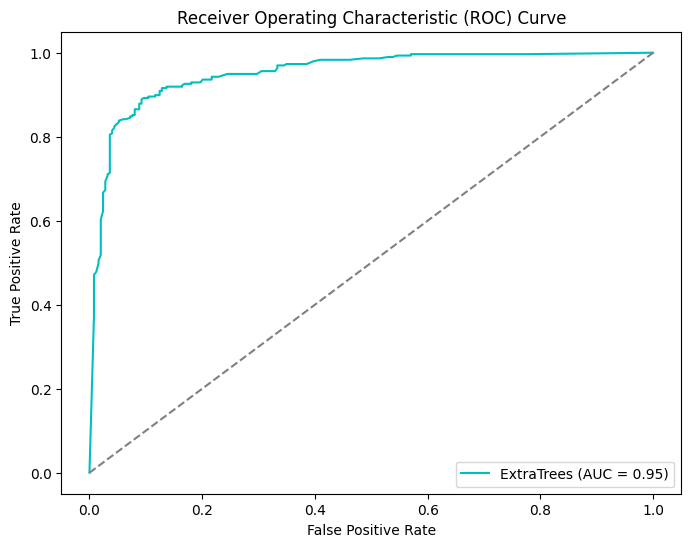

In [ ]:

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='c', label=f'ExtraTrees (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


INTERNAL VALIDATION- CROSS VALIDATION
cross validation is something that where instead of single train and split cross validation does multiple test and train to validate model

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(et, X, Y, cv=10, scoring='accuracy')
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores)} ± {np.std(cv_scores)}")

Cross-validation accuracy scores: [0.62637363 0.7032967  0.64835165 0.54395604 0.58241758 0.49450549
 0.54945055 0.77900552 0.83425414 0.74585635]
Mean Accuracy: 0.6507467670451096 ± 0.1064320332466018


since the cross validations model with stratifying the scores went belowor equals to 0.5 so we are using stratified fold

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(et, X, Y, cv=skf, scoring='accuracy')

print(f"Stratified K-Fold Accuracy: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores)} ± {np.std(cv_scores)}")


Stratified K-Fold Accuracy: [0.90659341 0.89010989 0.92857143 0.89010989 0.88461538 0.9010989
 0.88461538 0.87845304 0.90607735 0.92265193]
Mean Accuracy: 0.8992896606156275 ± 0.01593511353897866


 ExtraTreesClassifier model using pickle and joblib. Both methods allow you to reload the model later without retraining but we have used the pickel

In [ ]:
import pickle

# Save model
with open("extratrees_model.pkl", "wb") as model_file:
    pickle.dump(et, model_file)

# Load model
with open("extratrees_model.pkl", "rb") as model_file:
    loaded_model = pickle.load(model_file)

# Test loaded model
y_pred_loaded = loaded_model.predict(X_test)
print(f"Loaded Model Accuracy: {accuracy_score(Y_test, y_pred_loaded)}")


Loaded Model Accuracy: 0.8937728937728938


In [ ]:
import pandas as pd

# Load unknown data
unknown_df = pd.read_excel("/content/combined unkknown.xlsx")

In [ ]:
unknown_df

,IMPPAT_id,AD2D92,AD2D169,AD2D170,AD2D247,AD2D404,AD2D481,AD2D482,AD2D492,AD2D559,...,BCUT2D_CHGHI_1.0,BCUT2D_CHGLO_1.0,BCUT2D_MRHI_2.0,Chi4n_0,PEOE_VSA6_0,SlogP_VSA11_0,RingCount_0,fr_NH0_0,fr_aniline_0,fr_aryl_methyl_0
0,Â IMPHY005665,0,0,0,0,1,0,0,0,0,...,0,1,0,0,1,1,0,0,1,1
1,IMPHY004660,0,0,0,0,0,0,0,1,0,...,0,0,1,1,1,1,1,1,1,1
2,IMPHY012021,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,1,1,1,1
3,IMPHY011844,0,0,0,0,0,0,0,1,0,...,1,1,0,1,1,1,1,1,1,1
4,IMPHY004978,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Â IMPHY006342,1,0,0,0,0,0,1,1,0,...,0,1,0,1,1,1,1,0,1,1
124,IMPHY001869,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,1,1,1,1,1
125,Â IMPHY010284,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,1,1,1,1,1
126,IMPHY011619,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,1


In [ ]:
unknown_df.head(5)

,IMPPAT_id,AD2D92,AD2D169,AD2D170,AD2D247,AD2D404,AD2D481,AD2D482,AD2D492,AD2D559,...,BCUT2D_CHGHI_1.0,BCUT2D_CHGLO_1.0,BCUT2D_MRHI_2.0,Chi4n_0,PEOE_VSA6_0,SlogP_VSA11_0,RingCount_0,fr_NH0_0,fr_aniline_0,fr_aryl_methyl_0
0,Â IMPHY005665,0,0,0,0,1,0,0,0,0,...,0,1,0,0,1,1,0,0,1,1
1,IMPHY004660,0,0,0,0,0,0,0,1,0,...,0,0,1,1,1,1,1,1,1,1
2,IMPHY012021,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,1,1,1,1
3,IMPHY011844,0,0,0,0,0,0,0,1,0,...,1,1,0,1,1,1,1,1,1,1
4,IMPHY004978,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1


In [ ]:
# Get the feature names used during training
training_features = loaded_model.feature_names_in_

# Select only the necessary columns from unknown_df, and reorder them
unknown_df = unknown_df.reindex(columns=training_features)


In [ ]:
# Predict class labels
predictions = loaded_model.predict(unknown_df)

# Predict probabilities (if needed)
probabilities = loaded_model.predict_proba(unknown_df)

original_unknown_df = pd.read_excel("/content/combined unkknown.xlsx")
IMPPAT_ids = original_unknown_df["IMPPAT_id"]

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame({
    "IMPPAT_id": IMPPAT_ids,
    "Predicted_Class": predictions,
    "Probability_Class_0": probabilities[:, 0],  # Probability of class 0
    "Probability_Class_1": probabilities[:, 1]   # Probability of class 1
})

# Save predictions
predictions_df.to_csv("predictions.csv", index=False)
print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv


In [ ]:
df_check = pd.read_csv("predictions.csv")
print(df_check.head())  # Check if the order looks correct


       IMPPAT_id  Predicted_Class  Probability_Class_0  Probability_Class_1
0  Â IMPHY005665                0             0.510000             0.490000
1    IMPHY004660                1             0.420000             0.580000
2    IMPHY012021                0             0.646667             0.353333
3    IMPHY011844                1             0.380000             0.620000
4    IMPHY004978                1             0.455000             0.545000
